# 02 — Retention analysis and activity patterns

Rebuilds the retention curve in pandas as an independent check on the SQL implementation, then opens up activity patterns — how often players return, whether the week has a rhythm, and what the daily player count looks like over the window.

**Inputs:** `day_0.csv`, `user_journal.csv` from `01_retention_extraction.ipynb`.
**Produces:** no files — this notebook is analysis. Its output is findings and the specification for the pulls in notebook 03.
**Next:** the DAU anomaly found in the second half of this notebook is investigated in `04_spike_analysis.ipynb`, using an extraction designed here.

Every retention number below is cross-checked against `sql/retention_curve.sql`. Two independent implementations agreeing digit-for-digit is the point — a single implementation agreeing with itself proves nothing.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
day_0 = pd.read_csv('day_0.csv', parse_dates = ['day_0'])
user_journal = pd.read_csv('user_journal.csv', parse_dates = ['active_day'])

In [3]:
print(day_0.shape)
print(day_0.dtypes)
display(day_0.head())
print(user_journal.shape)
print(user_journal.dtypes)
display(user_journal.head())

(4319, 2)
user_pseudo_id            object
day_0             datetime64[ns]
dtype: object


,user_pseudo_id,day_0
0,1814A35D096333518F94B02DDFE3BFEC,2018-06-15
1,4F8458200DBF0AD3A4B095CA35EEA47C,2018-06-15
2,6B41795D5E5B7339E007330941C9E201,2018-06-15
3,0FB42D5FFB79A9DE147873753BF7A664,2018-07-15
4,61C77C8D9E7F92524289DA7E9D4786BF,2018-07-15


(59037, 2)
user_pseudo_id            object
active_day        datetime64[ns]
dtype: object


,user_pseudo_id,active_day
0,102CC7D8CD5D3E861EACE1BAB97E61EC,2018-06-26
1,D5AA8A02352703280A47B61A01621DD2,2018-06-26
2,1F25763EC8BCAEC7FB069E81659A2153,2018-06-26
3,CAB801809B633E8717EB78894D440EBF,2018-06-26
4,2741C47CC50AE98B39CC5B561BFEA504,2018-06-26


## Retention pipeline

Mirrors the CTE chain in `sql/retention_curve.sql`: join each cohort user to their active days, convert to days-since-install, flag whether each user was present on exactly day N, then divide by the users eligible to be observed that far out.

Three definitions are locked here and matter more than the code:

- **Day 0** is the user's earliest `first_open` date. Calendar days, GA4 convention.
- **Retained on day N** means at least one event of any type on exactly day 0 + N. Not "day N or later" — this is the standard exact-day definition, and it is why a user can miss day 1 and still return later.
- **Eligible for day N** means day 0 falls at least N days before the window closes on 3 Oct 2018. Without per-N denominators, later Ns get silently penalised for users who simply ran out of window.

In [4]:
day_0_x_active_day = pd.merge(day_0, user_journal, on = 'user_pseudo_id', how = 'inner')
print(day_0_x_active_day.shape)
day_0_x_active_day

(11346, 3)


,user_pseudo_id,day_0,active_day
0,1814A35D096333518F94B02DDFE3BFEC,2018-06-15,2018-06-15
1,4F8458200DBF0AD3A4B095CA35EEA47C,2018-06-15,2018-06-16
2,4F8458200DBF0AD3A4B095CA35EEA47C,2018-06-15,2018-06-15
3,6B41795D5E5B7339E007330941C9E201,2018-06-15,2018-06-17
4,6B41795D5E5B7339E007330941C9E201,2018-06-15,2018-06-15
...,...,...,...
11341,383F4B98EC31DD2A915427D36A30354E,2018-08-04,2018-08-08
11342,383F4B98EC31DD2A915427D36A30354E,2018-08-04,2018-08-13
11343,CCADFC0ECC097AA5DA4FD3917D517022,2018-08-04,2018-08-04
11344,4542CFA974FAA3C923527BDDA50397B0,2018-08-04,2018-08-04


In [5]:
day_0_x_active_day['days_between'] = (day_0_x_active_day['active_day'] - day_0_x_active_day['day_0']).dt.days
print(day_0_x_active_day.shape)
display(day_0_x_active_day.head())
print(day_0_x_active_day['days_between'].min())
print(day_0_x_active_day['days_between'].max())

(11346, 4)


,user_pseudo_id,day_0,active_day,days_between
0,1814A35D096333518F94B02DDFE3BFEC,2018-06-15,2018-06-15,0
1,4F8458200DBF0AD3A4B095CA35EEA47C,2018-06-15,2018-06-16,1
2,4F8458200DBF0AD3A4B095CA35EEA47C,2018-06-15,2018-06-15,0
3,6B41795D5E5B7339E007330941C9E201,2018-06-15,2018-06-17,2
4,6B41795D5E5B7339E007330941C9E201,2018-06-15,2018-06-15,0


-96
111


In [6]:
contaminated = day_0_x_active_day[day_0_x_active_day['days_between'] < 0]
print(contaminated.shape)
print(contaminated['user_pseudo_id'].nunique())


(130, 4)
12


In [7]:
day_0_x_active_day['retained_d1'] = day_0_x_active_day['days_between'] == 1
day_0_x_active_day['retained_d3'] = day_0_x_active_day['days_between'] == 3
day_0_x_active_day['retained_d7'] = day_0_x_active_day['days_between'] == 7
day_0_x_active_day['retained_d14'] = day_0_x_active_day['days_between'] == 14
day_0_x_active_day['retained_d30'] = day_0_x_active_day['days_between'] == 30

# 'any', not 'sum': the question is whether the user was present on day N, not how many times.
# The journal is DISTINCT on (user, day), so days_between == N can be true at most once per
# user and sum returns identical numbers today — but it encodes the wrong question, and it
# would break silently if the input grain ever changed.
player_flags = day_0_x_active_day.groupby('user_pseudo_id', as_index = False).agg({'day_0': 'first', 'retained_d1': 'any', 'retained_d3': 'any', 'retained_d7': 'any', 'retained_d14': 'any', 'retained_d30': 'any'})
display(player_flags.head())
print(player_flags.shape)

,user_pseudo_id,day_0,retained_d1,retained_d3,retained_d7,retained_d14,retained_d30
0,000A8B9167F5F9B7BF620708D320E32F,2018-07-25,False,False,False,False,False
1,0018E9BAF92AFA2FFFCDCB5F48A3B134,2018-10-02,False,False,False,False,False
2,00353D3418DD0707FE0A80A59FBD5705,2018-09-11,True,True,False,False,False
3,0043CF8841C819015ACD25710D333113,2018-07-26,True,False,False,False,False
4,005F127942F3FD25588272950FDFD339,2018-08-15,False,False,False,False,False


(4319, 7)


In [8]:
cutoffs = {
    'd1': (1, '2018-10-02'),
    'd3': (3, '2018-09-30'),
    'd7': (7, '2018-09-26'),
    'd14': (14, '2018-09-19'),
    'd30': (30, '2018-09-03')
}

rows = []
for day, (day_num, date) in cutoffs.items():
    eligible = player_flags[player_flags['day_0'] <= date]

    n_eligible = eligible.shape[0]
    n_retained = eligible[f'retained_{day}'].sum()
    pct = round(100 * n_retained / n_eligible, 2) if n_eligible > 0 else 0

    rows.append({
        'N': day,
        'N_days': day_num,
        'eligible': n_eligible,
        'retained': n_retained,
        'rate_pct': pct
    })

retention_long = pd.DataFrame(rows)
retention_long

,N,N_days,eligible,retained,rate_pct
0,d1,1,4251,915,21.52
1,d3,3,4151,435,10.48
2,d7,7,3998,223,5.58
3,d14,14,3711,137,3.69
4,d30,30,2963,62,2.09


## The curve, and whether one decay law describes it

Two plots for two audiences. The linear one is the stakeholder view, with the y-axis honestly anchored at zero. The log-log one is a diagnostic: a power law `y = A·N^k` is a straight line in log-log space, so straightness tests whether a single decay law summarises the whole curve.

The cells after the plots make that test explicit. Segment slopes alternate around roughly −0.7 with no monotone trend — a trend would suggest the decay regime changes partway, alternation suggests noise. The standard errors then check whether the visible bends at D14 and D30 are large enough to mean anything.

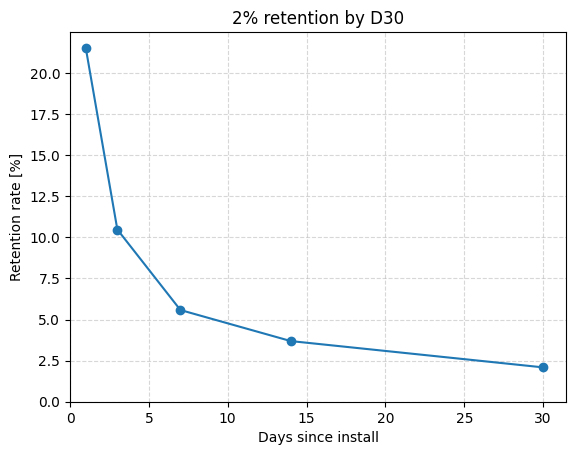

In [9]:
retention_graph_simplified = retention_long.plot(x = 'N_days', y = 'rate_pct' , marker = 'o', legend = False)

plt.title('2% retention by D30')
plt.xlabel('Days since install')
plt.xlim(left = 0)
plt.ylabel('Retention rate [%]')
plt.ylim(bottom = 0)
plt.grid(alpha = 0.5, linestyle = '--')

plt.show(retention_graph_simplified)

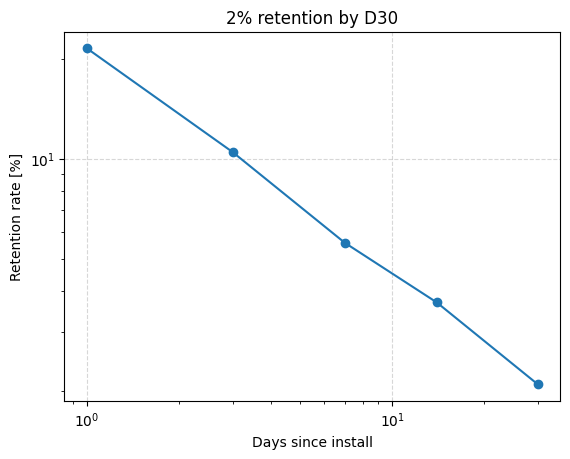

In [10]:
retention_graph_loglog = retention_long.plot(x = 'N_days', y = 'rate_pct', marker = 'o', legend = False)

plt.title('2% retention by D30')
plt.xlabel('Days since install')
plt.xscale('log')
plt.ylabel('Retention rate [%]')
plt.yscale('log')
plt.grid(alpha = 0.5, linestyle = '--')

plt.show(retention_graph_loglog)

In [11]:
slopes = np.diff(np.log(retention_long['rate_pct'])) / np.diff(np.log(retention_long['N_days']))
print(slopes)

[-0.65492992 -0.74387052 -0.59664431 -0.74587655]


In [12]:
d14_eligibles = retention_long['eligible'].loc[retention_long['N_days'] == 14].item()
d14_retained = retention_long['retained'].loc[retention_long['N_days'] == 14].item()
d14_p = d14_retained / d14_eligibles
d14_se_pp = round(100 * np.sqrt((d14_p * (1 - d14_p) / d14_eligibles)), 2)

d30_eligibles = retention_long['eligible'].loc[retention_long['N_days'] == 30].item()
d30_retained = retention_long['retained'].loc[retention_long['N_days'] == 30].item()
d30_p = d30_retained / d30_eligibles
d30_se_pp = round(100 * np.sqrt((d30_p * (1 - d30_p) / d30_eligibles)), 2)

print(d14_se_pp)
print(d30_se_pp)

0.31
0.26


In [13]:
code_check = []

d1_rate = retention_long['rate_pct'].loc[retention_long['N_days'] == 1].item()

d14_rate = retention_long['rate_pct'].loc[retention_long['N_days'] == 14].item()
d14_day = retention_long['N_days'].loc[retention_long['N_days'] == 14].item()

d30_rate = retention_long['rate_pct'].loc[retention_long['N_days'] == 30].item()
d30_day = retention_long['N_days'].loc[retention_long['N_days'] == 30].item()

code_check.append([d14_rate, d14_day, d14_se_pp])
code_check.append([d30_rate, d30_day, d30_se_pp])

for rate, day, se in code_check:
   print(-2 * se <= rate - d1_rate*day**-0.69 <= 2 * se)

True
True


## How many days does a player actually play?

Retention asks about specific days. This asks about totals: across the whole window, on how many distinct days was each of the 15,175 players active?

Players are tagged cohort or pre-window, and the two groups are **not** comparable on equal terms. Pre-window players are seen only from 12 Jun onward, so their counts undercount their real lifetimes; cohort players are seen from install but are cut off at the window's end. The histogram uses explicit shared bin edges — integer `bins=` would slice each group over its own range and produce different bin widths per group, making the two distributions visually incomparable.

In [14]:
active_days_per_user = user_journal.groupby('user_pseudo_id', as_index = False).count().sort_values(by = 'active_day', ascending = False)
active_days_per_user.rename(columns = {'active_day': 'n_active_day'}, inplace = True)
active_days_per_user['in_cohort'] = active_days_per_user['user_pseudo_id'].isin(day_0['user_pseudo_id'])
active_days_per_user['only_1_day'] = active_days_per_user['n_active_day'] == 1

display(active_days_per_user)

in_cohort_flags = active_days_per_user.groupby('in_cohort')['n_active_day'].describe()
display(in_cohort_flags)

only_1_day_dist = active_days_per_user.groupby('in_cohort')['only_1_day'].describe()
display(only_1_day_dist)

,user_pseudo_id,n_active_day,in_cohort,only_1_day
3313,372D9BB5088C4E9000C65B06459B403A,114,False,False
757,0C777BD44F304574371C97674DCD0702,108,False,False
10970,B5395F8C2077B59B3D6C5719C0CA0339,107,False,False
6938,7386D239899D55E3D62DA619F359A7C0,105,False,False
3400,3875A92B5F5C2BBA1355CED06A986079,105,False,False
...,...,...,...,...
10,0018E9BAF92AFA2FFFCDCB5F48A3B134,1,True,True
9,0015EE183D5A306035B51F4F6CE1E6FE,1,False,True
5,000E838887A9BD8B91A01FBA91CA69C5,1,False,True
4,000CDB12737C5ADB8C30E19BB209B805,1,False,True


,count,mean,std,min,25%,50%,75%,max
in_cohort,,,,,,,,
False,10856.0,4.393055,9.613191,1.0,1.0,1.0,3.0,114.0
True,4319.0,2.626997,4.379943,1.0,1.0,1.0,3.0,80.0


,count,unique,top,freq
in_cohort,,,,
False,10856,2,True,5515
True,4319,2,True,2341


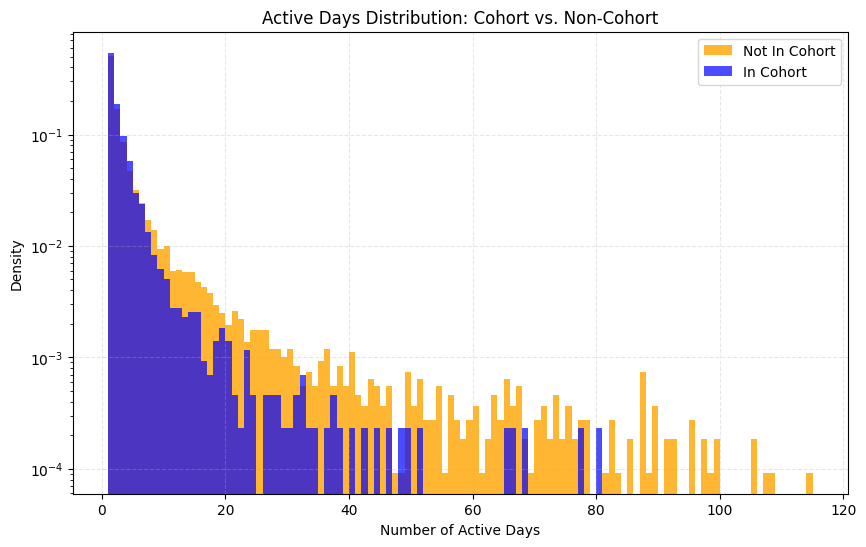

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

active_days_per_user[active_days_per_user['in_cohort'] == False]['n_active_day'].plot(
    kind='hist',
    bins=range(1, 116),
    ax=ax,
    density=True,
    color='orange',
    alpha=0.8,
    label='Not In Cohort'
)

active_days_per_user[active_days_per_user['in_cohort'] == True]['n_active_day'].plot(
    kind='hist',
    bins=range(1, 116),
    ax=ax,
    density=True,
    color='blue',
    alpha=0.7,
    label='In Cohort'
)

plt.title('Active Days Distribution: Cohort vs. Non-Cohort')
plt.xlabel('Number of Active Days')
plt.ylabel('Density')
plt.yscale('log')
plt.grid(alpha=0.3, linestyle='--')
plt.legend()

plt.show()

## Does the week have a rhythm?

A casual mobile game might reasonably show weekend peaks. Testing it needs a fair unit: total user-days per weekday is not comparable across weekdays, because the window does not contain equal numbers of each. Tuesdays and Wednesdays get 17 instances, the rest 16.

Dividing by the number of dates each weekday actually occurs gives average active users per day-instance. The result below is revisited later in this notebook — read it as a first pass, not a conclusion.

In [16]:
user_journal['weekday'] = user_journal['active_day'].dt.day_name()
user_journal['weekday_num'] = user_journal['active_day'].dt.dayofweek

user_journal

,user_pseudo_id,active_day,weekday,weekday_num
0,102CC7D8CD5D3E861EACE1BAB97E61EC,2018-06-26,Tuesday,1
1,D5AA8A02352703280A47B61A01621DD2,2018-06-26,Tuesday,1
2,1F25763EC8BCAEC7FB069E81659A2153,2018-06-26,Tuesday,1
3,CAB801809B633E8717EB78894D440EBF,2018-06-26,Tuesday,1
4,2741C47CC50AE98B39CC5B561BFEA504,2018-06-26,Tuesday,1
...,...,...,...,...
59032,BBD445CA32DF129E21FF7BB97DC3630A,2018-09-26,Wednesday,2
59033,53CAAF361073109F66760692FA12673B,2018-09-26,Wednesday,2
59034,FC3907C3039196E679F3C468FE5B1F9E,2018-09-26,Wednesday,2
59035,74EFA3B9E98982CB94246D7F95DF29D0,2018-09-26,Wednesday,2


In [17]:
user_journal_aggs = user_journal.groupby('weekday', as_index = False).agg(
    n_user_days=('user_pseudo_id','size'),
    n_players=('user_pseudo_id','nunique'),
    n_dates=('active_day','nunique'),
    weekday_num = ('weekday_num', 'max')
    ).sort_values('weekday_num')

user_journal_aggs['avg_per_weekday'] = user_journal_aggs['n_user_days'] / user_journal_aggs['n_dates']
user_journal_aggs

,weekday,n_user_days,n_players,n_dates,weekday_num,avg_per_weekday
1,Monday,9145,5093,16,0,571.562500
5,Tuesday,9329,5202,17,1,548.764706
6,Wednesday,7941,4412,17,2,467.117647
4,Thursday,8236,4673,16,3,514.750000
0,Friday,7646,4249,16,4,477.875000
2,Saturday,8483,4899,16,5,530.187500
3,Sunday,8257,4678,16,6,516.062500


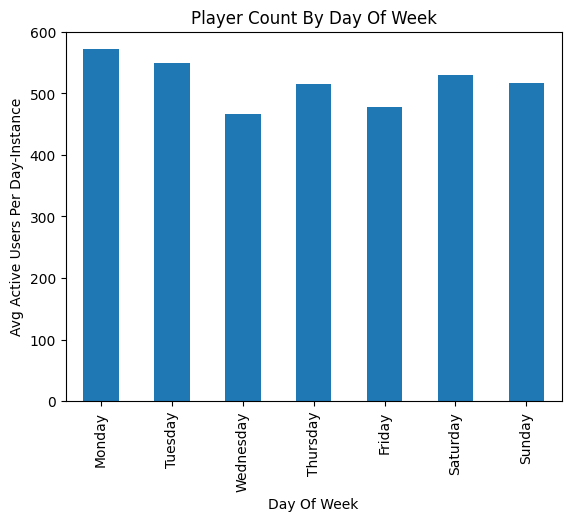

In [18]:
user_journal_aggs.plot(kind = 'bar', x = 'weekday', y = 'avg_per_weekday', legend = False)
plt.xlabel('Day Of Week')
plt.ylabel('Avg Active Users Per Day-Instance')
plt.title('Player Count By Day Of Week')
plt.show()

In [19]:
avg_per_weekend_day = user_journal_aggs[user_journal_aggs['weekday_num'] >= 5]['n_user_days'].sum() / user_journal_aggs[user_journal_aggs['weekday_num'] >= 5]['n_dates'].sum()
avg_per_weekday = user_journal_aggs[user_journal_aggs['weekday_num'] < 5]['n_user_days'].sum() / user_journal_aggs[user_journal_aggs['weekday_num'] < 5]['n_dates'].sum()

weekend_weekday_proportion = 100 * avg_per_weekend_day / avg_per_weekday - 100

print(avg_per_weekend_day)
print(avg_per_weekday)
print(weekend_weekday_proportion)

523.125
515.8170731707318
1.4167671466061336


## Daily player count over the window

Plotting DAU by date rather than by weekday, which is where the weekday result comes apart.

Seven days in late June carry roughly 2.5–3× the baseline player count, interleaved with normal days, and then never recur. The threshold below is a listing device, not a definition — every day above it is listed and inspected rather than being described from the ends of a sorted table.

In [20]:
active_days_daily_logs = user_journal.groupby(['active_day', 'weekday', 'weekday_num'], as_index = False).size()
active_days_daily_logs

,active_day,weekday,weekday_num,size
0,2018-06-12,Tuesday,1,449
1,2018-06-13,Wednesday,2,515
2,2018-06-14,Thursday,3,503
3,2018-06-15,Friday,4,488
4,2018-06-16,Saturday,5,421
...,...,...,...,...
109,2018-09-29,Saturday,5,564
110,2018-09-30,Sunday,6,519
111,2018-10-01,Monday,0,483
112,2018-10-02,Tuesday,1,495


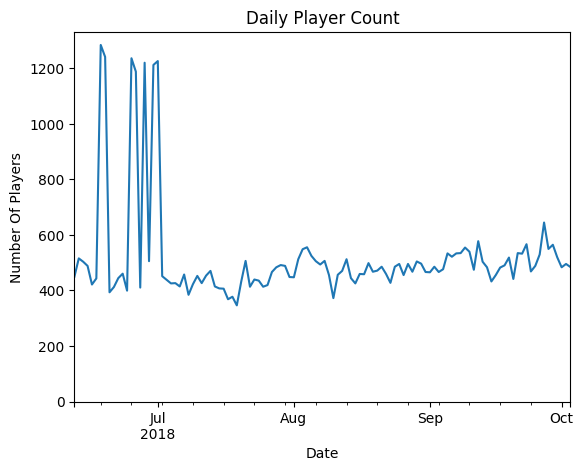

In [21]:
active_days_daily_logs.plot(kind = 'line', x ='active_day', y = 'size', legend = False)
plt.xlabel('Date')
plt.ylabel('Number Of Players')
plt.ylim(bottom = 0)
plt.title('Daily Player Count')
plt.show()

In [22]:
anomalies_in_question = active_days_daily_logs[active_days_daily_logs['size'] >= 600]
anomalies_in_question

,active_day,weekday,weekday_num,size
6,2018-06-18,Monday,0,1283
7,2018-06-19,Tuesday,1,1240
13,2018-06-25,Monday,0,1235
14,2018-06-26,Tuesday,1,1187
16,2018-06-28,Thursday,3,1219
18,2018-06-30,Saturday,5,1211
19,2018-07-01,Sunday,6,1225
107,2018-09-27,Thursday,3,644


## Re-testing the weekday rhythm without the June fortnight

The spike days are excluded by **date**, not by value. Cutting on the value would mean selecting on the outcome — remove every high day and the remaining days look flat by construction. Cutting at 2 Jul is a claim about a regime that ended, and it is falsifiable.

That leaves 94 stable days. The weekday averages are recomputed on those alone, and the gaps that survive are compared against what daily variation alone would produce.

In [23]:
active_days_daily_logs_no_anomalies = active_days_daily_logs[active_days_daily_logs['active_day'] >= '2018-07-02']

display(active_days_daily_logs_no_anomalies)
display(active_days_daily_logs_no_anomalies[['active_day', 'size']].describe())

,active_day,weekday,weekday_num,size
20,2018-07-02,Monday,0,451
21,2018-07-03,Tuesday,1,438
22,2018-07-04,Wednesday,2,425
23,2018-07-05,Thursday,3,426
24,2018-07-06,Friday,4,414
...,...,...,...,...
109,2018-09-29,Saturday,5,564
110,2018-09-30,Sunday,6,519
111,2018-10-01,Monday,0,483
112,2018-10-02,Tuesday,1,495


,active_day,size
count,94,94.000000
mean,2018-08-17 12:00:00,474.414894
min,2018-07-02 00:00:00,346.000000
25%,2018-07-25 06:00:00,441.750000
50%,2018-08-17 12:00:00,470.500000
75%,2018-09-09 18:00:00,504.750000
max,2018-10-03 00:00:00,644.000000
std,NaN,50.550392


In [24]:
weekday_stable = active_days_daily_logs_no_anomalies.groupby('weekday', as_index=False).agg(
    avg_players=('size', 'mean'),
    n_instances=('size', 'size'),
    weekday_num=('weekday_num', 'max')
).sort_values('weekday_num')

weekday_stable

,weekday,avg_players,n_instances,weekday_num
1,Monday,473.357143,14,0
5,Tuesday,460.928571,14,1
6,Wednesday,473.071429,14,2
4,Thursday,469.384615,13,3
0,Friday,477.615385,13,4
2,Saturday,491.615385,13,5
3,Sunday,476.153846,13,6


In [25]:
max_gap = weekday_stable['avg_players'].max() - weekday_stable['avg_players'].min()
print(max_gap)

30.686813186813197


In [26]:
pooled_weekday_avg = active_days_daily_logs_no_anomalies[active_days_daily_logs_no_anomalies['weekday_num'] < 5]['size'].sum() / active_days_daily_logs_no_anomalies[active_days_daily_logs_no_anomalies['weekday_num'] < 5].groupby('weekday')['active_day'].nunique().sum()
pooled_weekend_avg = active_days_daily_logs_no_anomalies[active_days_daily_logs_no_anomalies['weekday_num'] >= 5]['size'].sum() / active_days_daily_logs_no_anomalies[active_days_daily_logs_no_anomalies['weekday_num'] >= 5].groupby('weekday')['active_day'].nunique().sum()

weekday_weeked_gap = pooled_weekend_avg - pooled_weekday_avg

print(pooled_weekday_avg)
print(pooled_weekend_avg)
print(weekday_weeked_gap)

470.79411764705884
483.88461538461536
13.090497737556518


In [27]:
daily_std = active_days_daily_logs_no_anomalies['size'].std()

# A weekday mean averages ~13.4 day-instances, so its SE is the daily std over sqrt(n).
# Comparing two weekday means costs a further sqrt(2); 2 SE is the ~95% bar.
se_weekday = daily_std / np.sqrt(weekday_stable['n_instances'].mean())
pairwise_threshold = 2 * np.sqrt(2) * se_weekday

# Pooled test uses the real group sizes: 68 weekday instances against 26 weekend.
n_wd = weekday_stable[weekday_stable['weekday_num'] < 5]['n_instances'].sum()
n_we = weekday_stable[weekday_stable['weekday_num'] >= 5]['n_instances'].sum()
pooled_threshold = 2 * np.sqrt(daily_std**2 / n_wd + daily_std**2 / n_we)

print('daily std over stable window:', round(daily_std, 2))
print('max weekday gap:', round(max_gap, 2), '| pairwise threshold:', round(pairwise_threshold, 2))
print('weekend-weekday gap:', round(weekday_weeked_gap, 2), '| pooled threshold:', round(pooled_threshold, 2))

daily std over stable window: 50.55
max weekday gap: 30.69 | pairwise threshold: 39.02
weekend-weekday gap: 13.09 | pooled threshold: 23.31


## Anatomy of the spike days

Two questions: were these new players, and who was in the room?

Installs are checked against the spike dates directly, and the population mix is measured by tagging every user-day as pre-window or cohort. The last cell verifies that the seven days sitting between the spikes really are at baseline — they become the matched comparison group for notebook 04, and a comparison group has to be checked, not assumed.

In [28]:
installs_daily = day_0.groupby('day_0', as_index=False).size()
display(installs_daily)

installs_dailiy_anomalies_check = pd.merge(installs_daily, anomalies_in_question, left_on = 'day_0', right_on = 'active_day', how = 'inner')
display(installs_dailiy_anomalies_check)


,day_0,size
0,2018-06-12,25
1,2018-06-13,25
2,2018-06-14,40
3,2018-06-15,33
4,2018-06-16,25
...,...,...
104,2018-09-29,46
105,2018-09-30,38
106,2018-10-01,40
107,2018-10-02,60


,day_0,size_x,active_day,weekday,weekday_num,size_y
0,2018-06-19,10,2018-06-19,Tuesday,1,1240
1,2018-06-26,1,2018-06-26,Tuesday,1,1187
2,2018-09-27,26,2018-09-27,Thursday,3,644


In [29]:
anomalies_in_question[~anomalies_in_question['active_day'].isin(day_0['day_0'])]

,active_day,weekday,weekday_num,size
6,2018-06-18,Monday,0,1283
13,2018-06-25,Monday,0,1235
16,2018-06-28,Thursday,3,1219
18,2018-06-30,Saturday,5,1211
19,2018-07-01,Sunday,6,1225


In [30]:
spike_dates = pd.to_datetime(['2018-06-18','2018-06-19','2018-06-25','2018-06-26','2018-06-28','2018-06-30','2018-07-01'])

user_journal['is_spike_day'] = user_journal['active_day'].isin(spike_dates)
user_journal['is_prewindow'] = ~user_journal['user_pseudo_id'].isin(day_0['user_pseudo_id'])

user_journal.groupby('is_spike_day')['is_prewindow'].mean()

,is_prewindow
is_spike_day,
False,0.779745
True,0.972442


In [31]:
interleaved_candidates = pd.to_datetime(['2018-06-20', '2018-06-21', '2018-06-22', '2018-06-23', '2018-06-24', '2018-06-27', '2018-06-29'])

active_days_daily_logs[active_days_daily_logs['active_day'].isin(interleaved_candidates)]

,active_day,weekday,weekday_num,size
8,2018-06-20,Wednesday,2,393
9,2018-06-21,Thursday,3,412
10,2018-06-22,Friday,4,444
11,2018-06-23,Saturday,5,460
12,2018-06-24,Sunday,6,399
15,2018-06-27,Wednesday,2,410
17,2018-06-29,Friday,4,505


## What this notebook establishes

**Retention.** D1 21.5%, D3 10.5%, D7 5.6%, D14 3.7%, D30 2.1% — matching the SQL implementation digit-for-digit across all fifteen numbers. Five points consistent with a single power law of exponent ≈ −0.7, with the D14 and D30 deviations inside two standard errors.

**Return behaviour.** Roughly half of all players are active on exactly one day. D1 retention alone undercounts recoverable players: a substantial share of the cohort misses day 1 and returns later, because retention is defined on exact days.

**The weekly rhythm is noise.** The apparent Monday/Tuesday peak was the June fortnight in costume. On the 94 stable days, no weekday gap and no weekend-versus-weekday gap survives comparison against daily variation.

**Seven anomalous days, unexplained here.** ~2.5–3× baseline players, interleaved with normal days, then never again. Installs did not rise with them — five of the seven logged no installs at all — and the crowd was almost entirely pre-window players.

**Not concluded here.** Why the seven days happened. Three hypotheses stand open at this point — re-engagement of the installed base, an in-game or seasonal event, or a data artifact — and none can be separated with day-grain data. Notebook 03 extracts event-level composition for those days; notebook 04 reaches the verdict. Also open: whether pre-window players are genuinely more dedicated than cohort players, which the deep tail hints at but censoring cannot be separated from.